In [1]:
import os

import ale_py

import pandas as pd
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecFrameStack, VecMonitor
from stable_baselines3.common.callbacks import ProgressBarCallback
from HelperAtari import evaluate_atari, render_callback_atari, plot_reward

In [2]:
env_id = "ALE/Pong-v5"

log_path = "monitor/Pong_ppo_monitor.csv"
if os.path.exists(log_path):
    os.remove(log_path)

env = make_atari_env(env_id, n_envs=8, wrapper_kwargs=dict(terminal_on_life_loss=False))
env = VecFrameStack(env, n_stack=4)
env = VecMonitor(env, filename=log_path)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/home/philipp.chorn/python/ReinforcementLearning/.venv/lib/python3.11/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


In [3]:
print("Observation space: ", env.observation_space)
print("Action space: ", env.action_space)

Observation space:  Box(0, 255, (84, 84, 4), uint8)
Action space:  Discrete(6)


In [4]:
model = PPO(
    policy="CnnPolicy",
    env=env,
    verbose=0
)

model.learn(5_000_000, progress_bar=True)

Output()

In [5]:
evaluate_atari(model, env_id)

/home/philipp.chorn/python/ReinforcementLearning/.venv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


mean_reward=-4.50 +/- 6.80


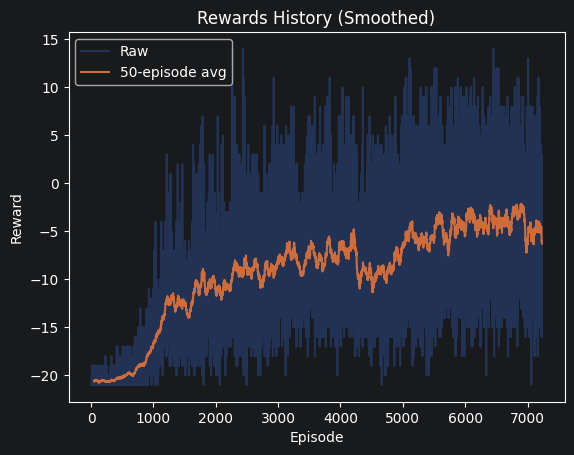

In [6]:
df = pd.read_csv(log_path, skiprows=1)
rewards = df["r"]

plot_reward(rewards)

In [7]:
model_name = "ppo-Pong"
model.save(model_name)
# model = PPO.load(model_name)

In [8]:
render_callback_atari(model, env_id)

ALSA lib .././../src/v1.2.13-3eeec0cd85.clean/src/confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib .././../src/v1.2.13-3eeec0cd85.clean/src/conf.c:5205:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib .././../src/v1.2.13-3eeec0cd85.clean/src/confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib .././../src/v1.2.13-3eeec0cd85.clean/src/conf.c:5205:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib .././../src/v1.2.13-3eeec0cd85.clean/src/confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib .././../src/v1.2.13-3eeec0cd85.clean/src/conf.c:5205:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib .././../src/v1.2.13-3eeec0cd85.clean/src/conf.c:5728:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib ../.././../src/v1.2.13-3eeec0cd85.clean/src/pcm/pcm.c:2722:(snd_pcm_open_noupdate) Unknown PCM de

error: video system not initialized